# Kiểm tra nhanh dữ liệu IR và MP2

Notebook này chỉ dùng để **quan sát và lọc dữ liệu xấu** trước khi train.

Cấu trúc:

```text
project/
├── inspect_ir_mp2_all_files.ipynb
└── input/
    ├── file1.csv
    ├── file2.csv
    └── ...
```

Với mỗi file CSV, notebook vẽ trên cùng một đồ thị:

- `IR_raw`
- `MP2_AO_raw`

Không sử dụng `MP2_DO`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (13, 5.5)
plt.rcParams["axes.grid"] = True

## 1. Đọc tất cả file CSV trong `input/`

In [2]:
INPUT_DIR = Path.cwd() / "input/train"

files = sorted(INPUT_DIR.glob("*.csv"))

if not files:
    raise FileNotFoundError(
        f"Không tìm thấy file CSV trong: {INPUT_DIR}"
    )

print(f"Tìm thấy {len(files)} file:")
for path in files:
    print("-", path.name)

Tìm thấy 36 file:
- giay1.csv
- giay10.csv
- giay11.csv
- giay2.csv
- giay3.csv
- giay4.csv
- giay5.csv
- giay6.csv
- giay7.csv
- giay8.csv
- giay9.csv
- log25.csv
- log26.csv
- log27.csv
- log28.csv
- log30.csv
- log31.csv
- log32.csv
- log33.csv
- log34.csv
- log35.csv
- log36.csv
- log37.csv
- log38.csv
- log39.csv
- log40.csv
- log41.csv
- log42.csv
- log43.csv
- log44.csv
- log45.csv
- log46.csv
- log47.csv
- log48.csv
- log49.csv
- log50.csv


## 2. Vẽ IR và MP2 của từng file

Trục X được ưu tiên theo thứ tự:

1. `time_from_trigger_s`
2. `time_s`
3. `sample`
4. index của DataFrame

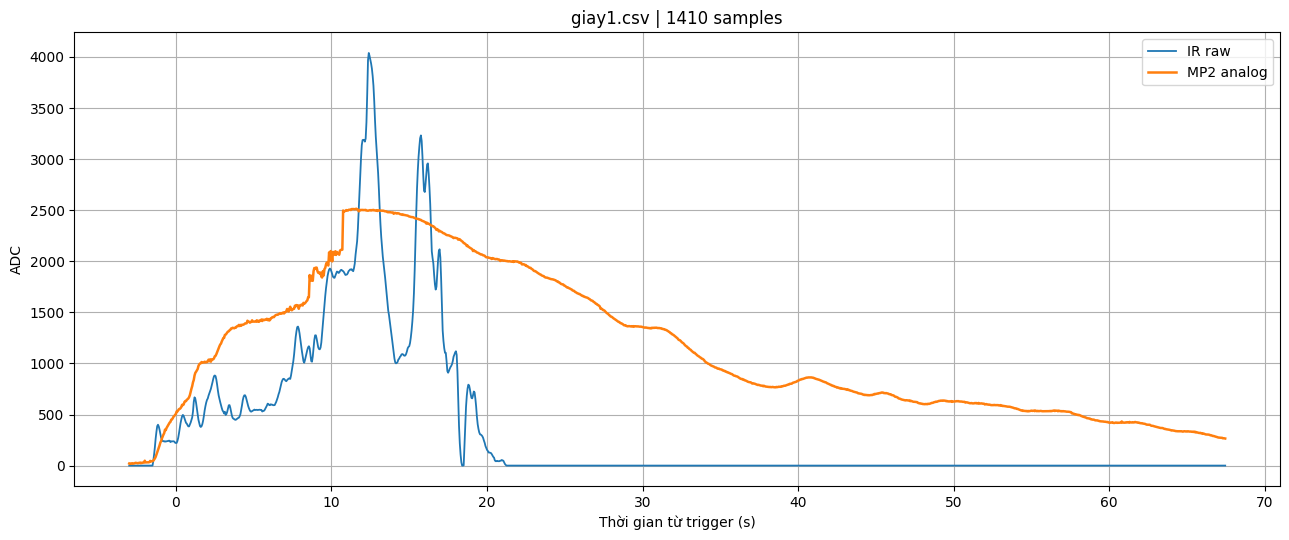

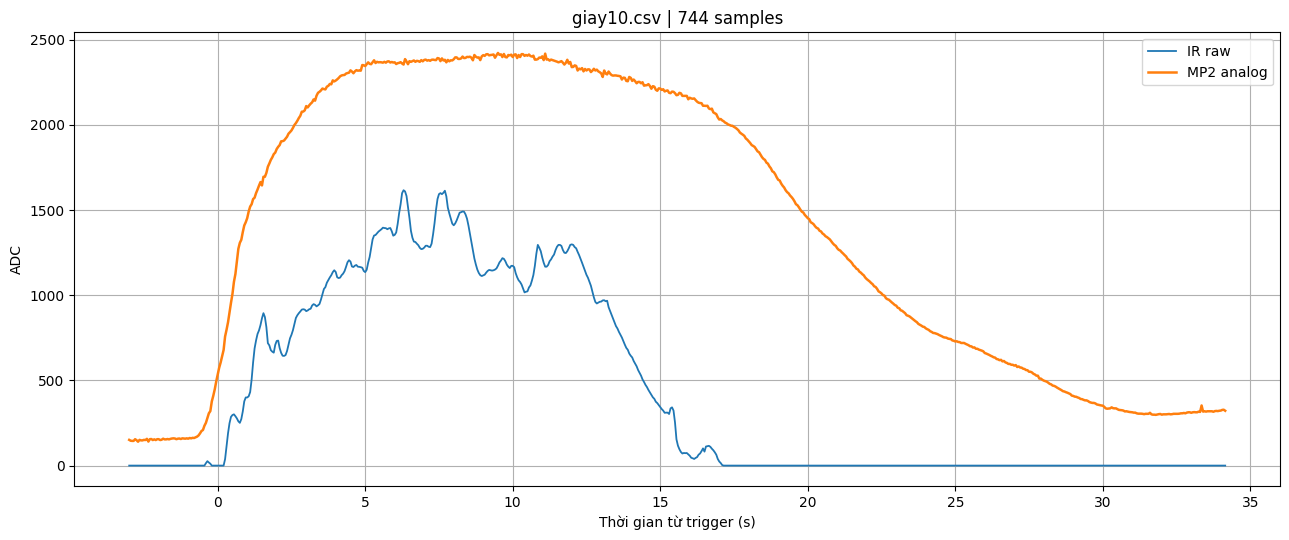

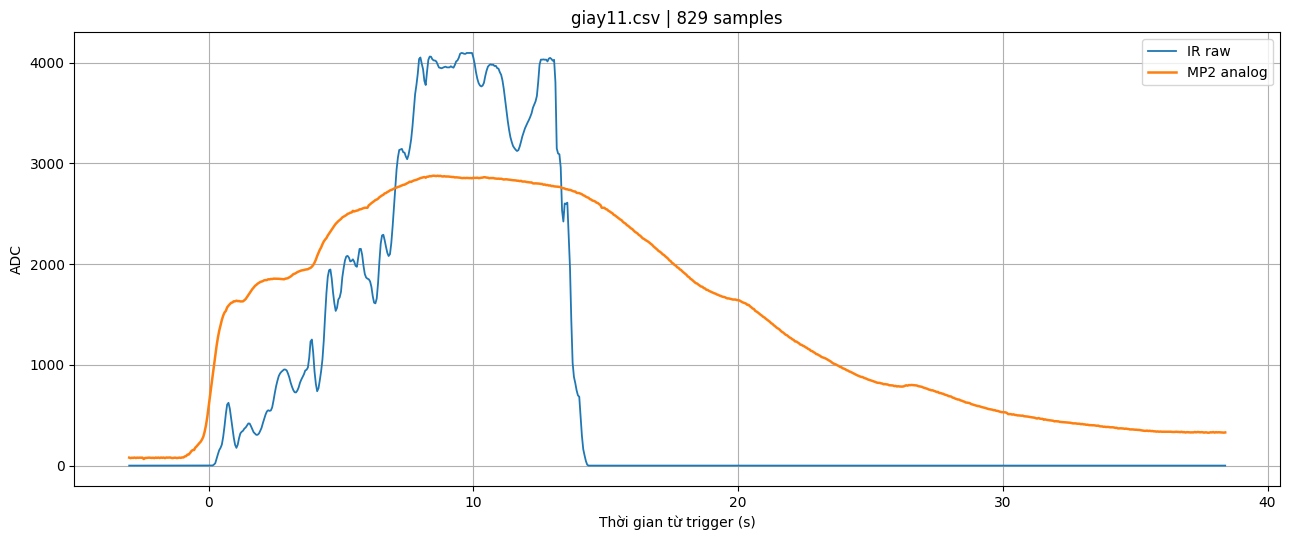

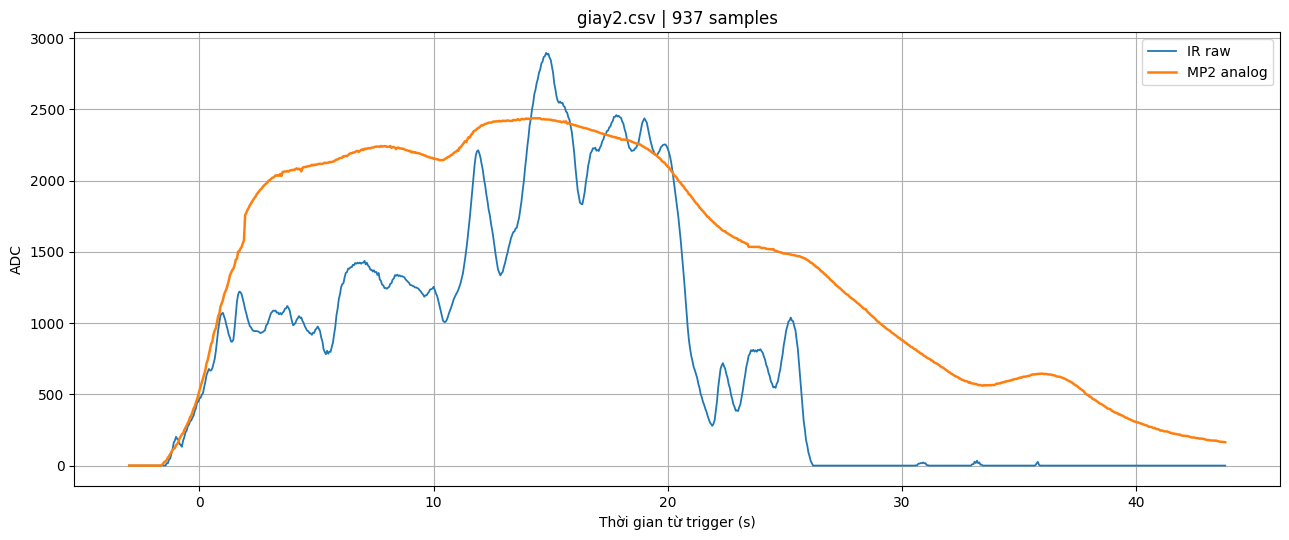

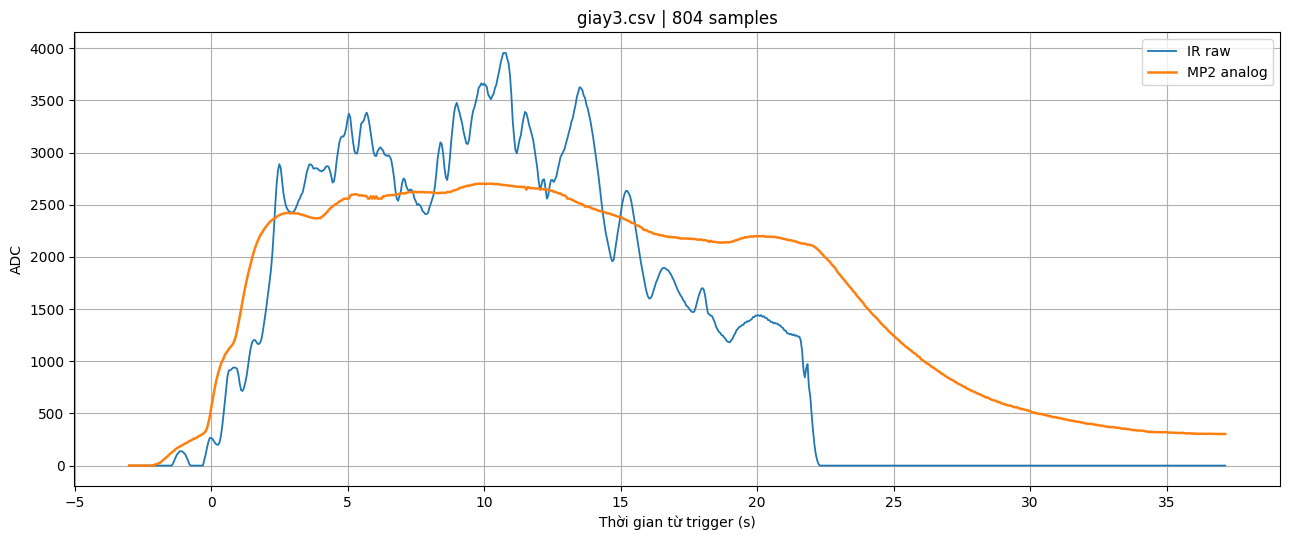

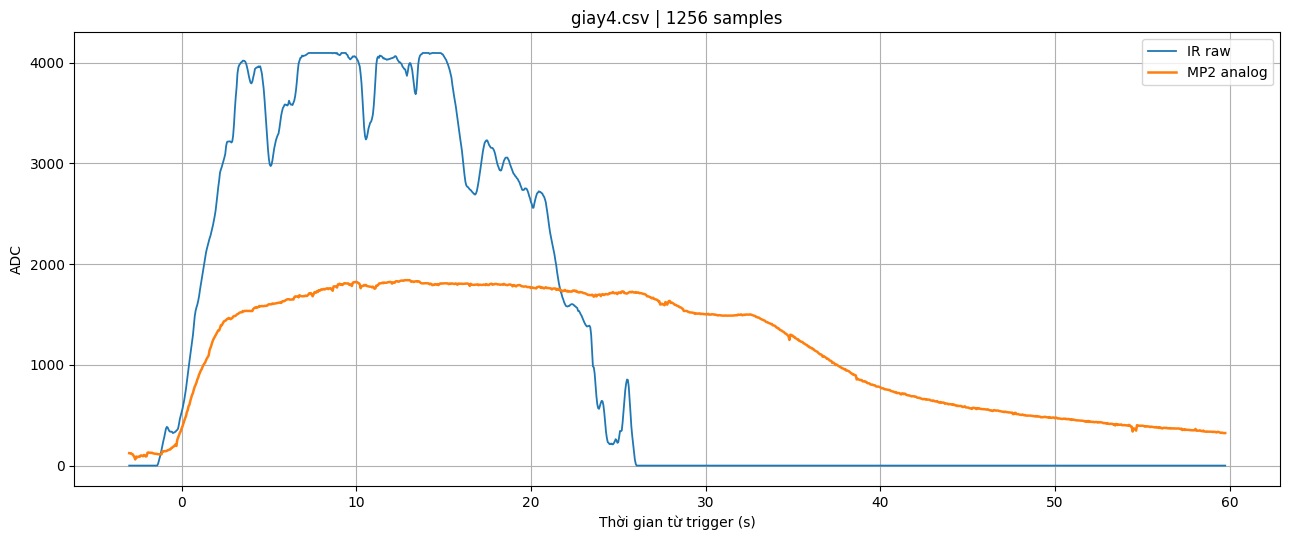

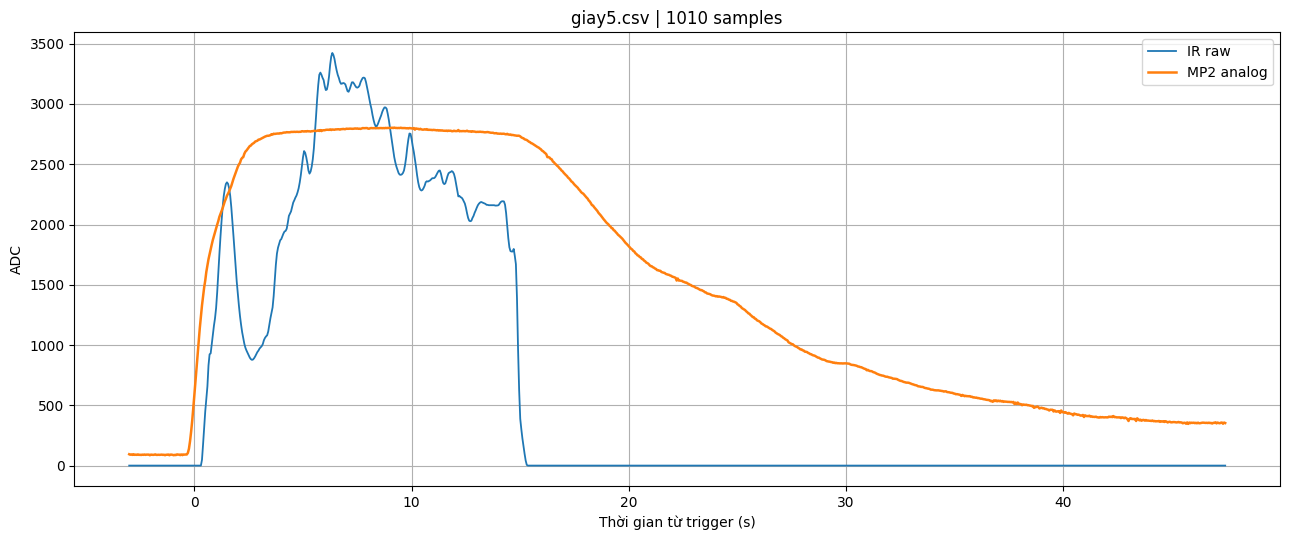

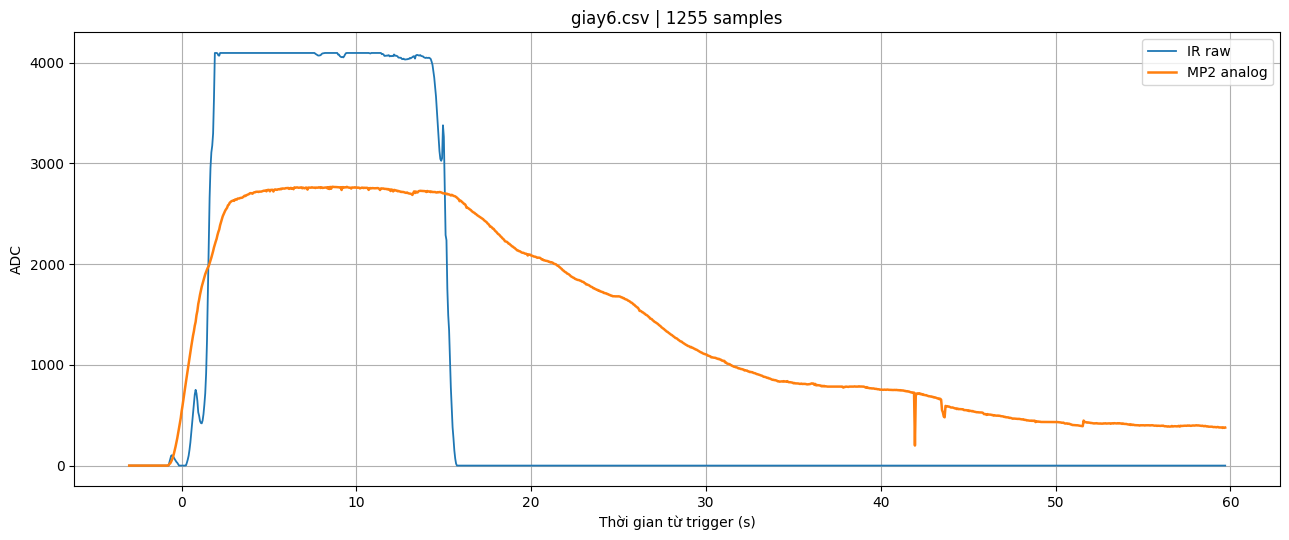

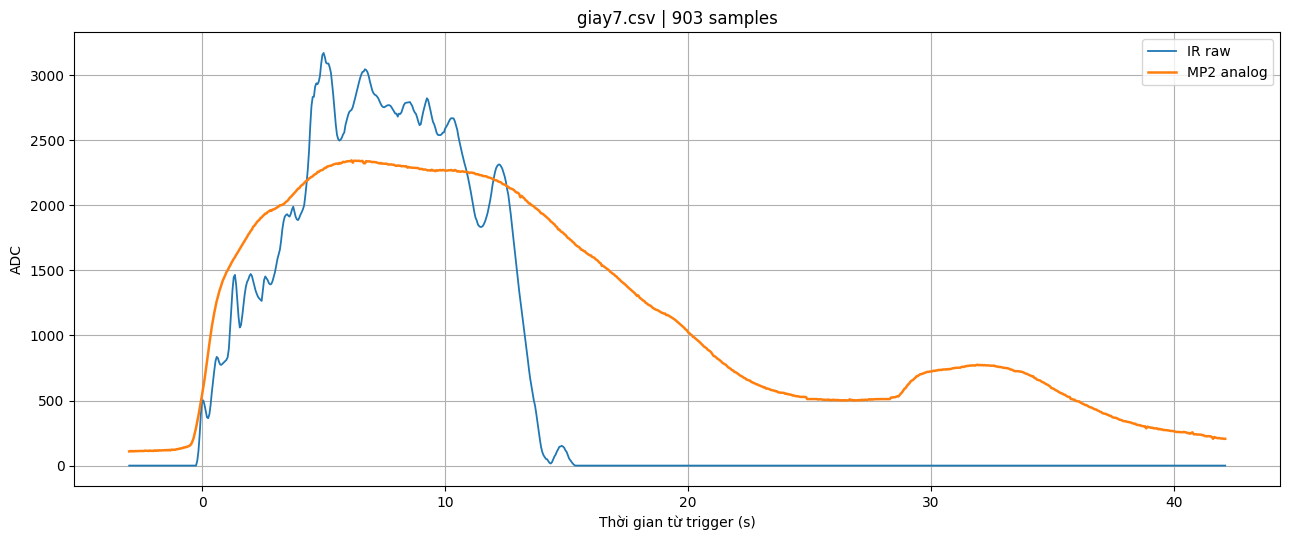

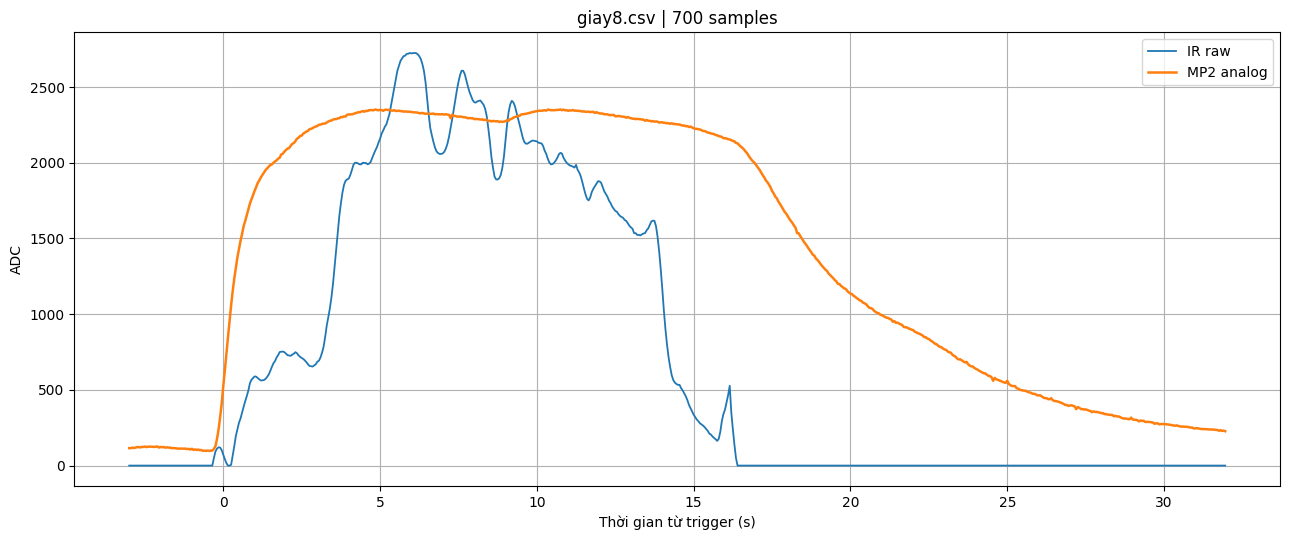

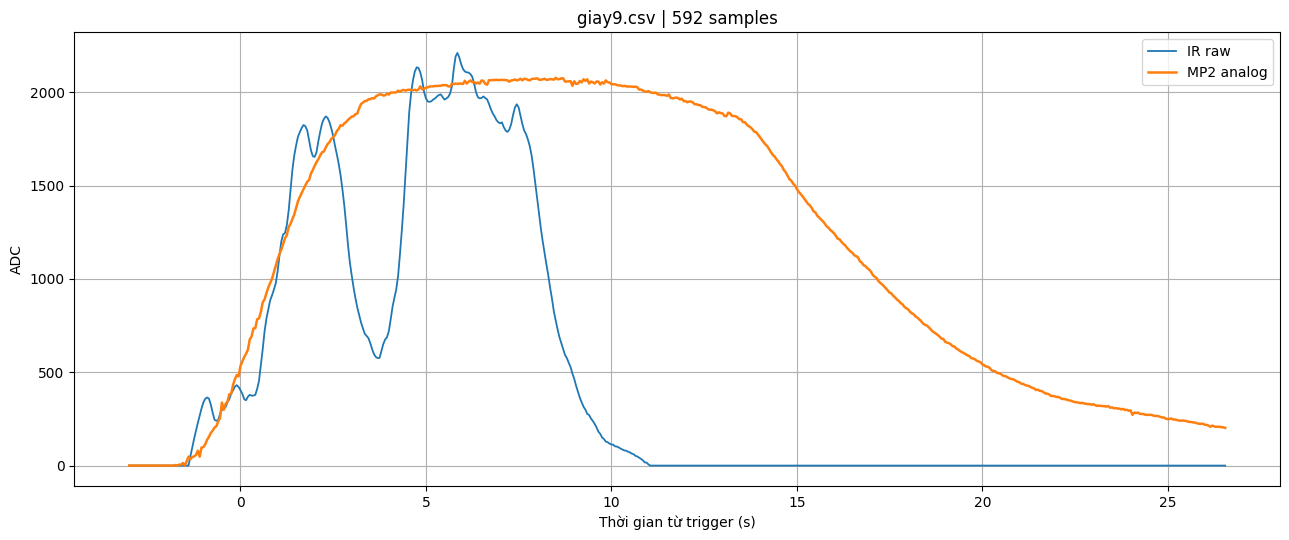

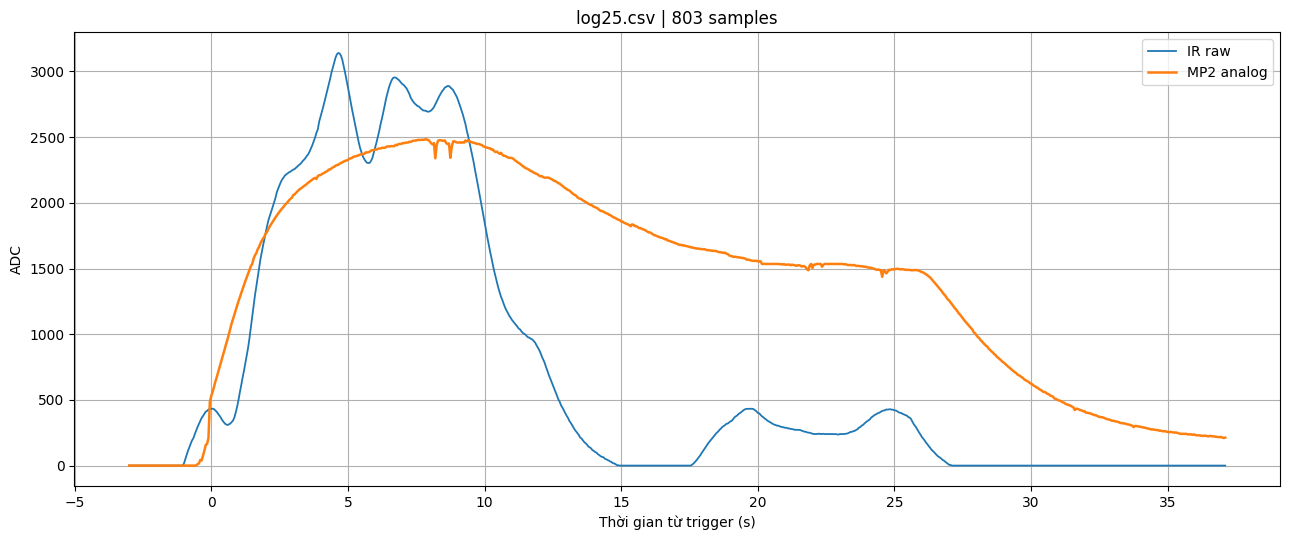

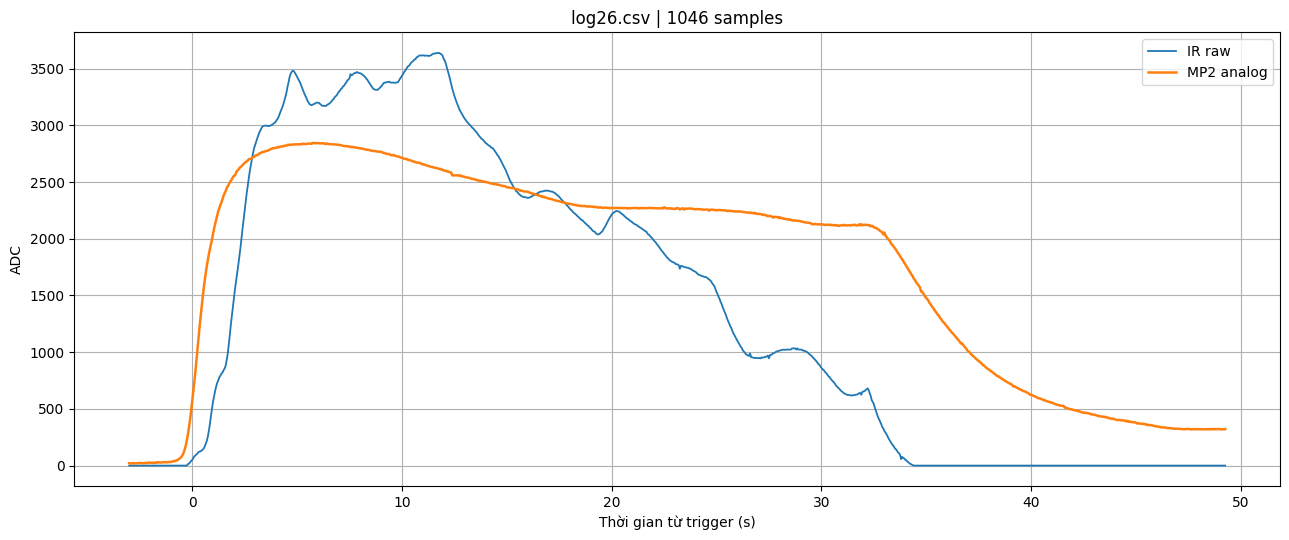

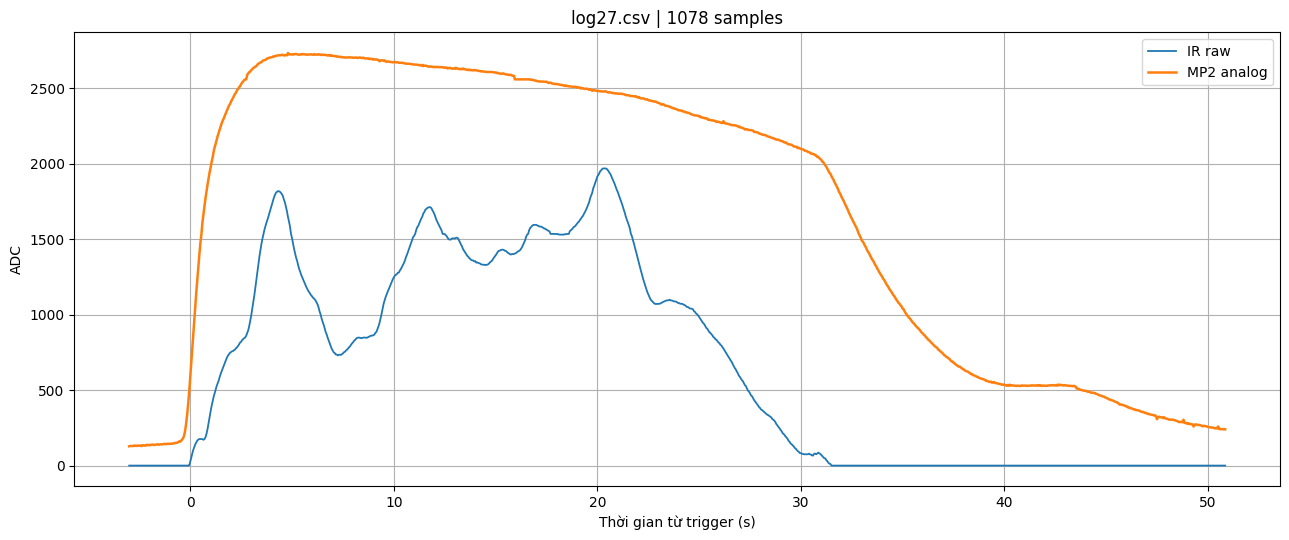

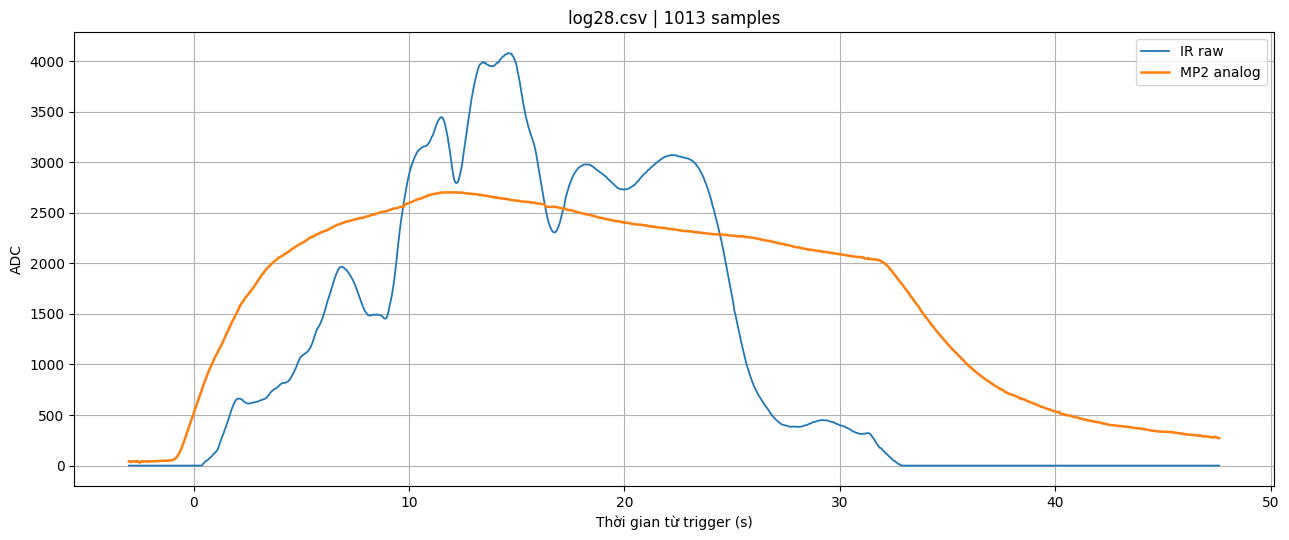

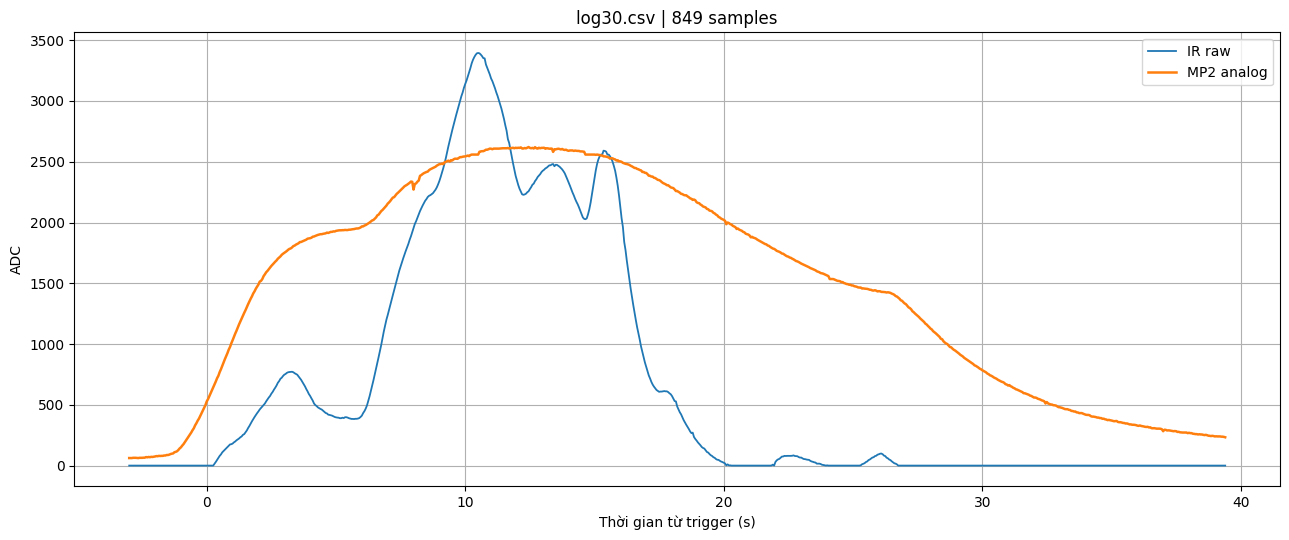

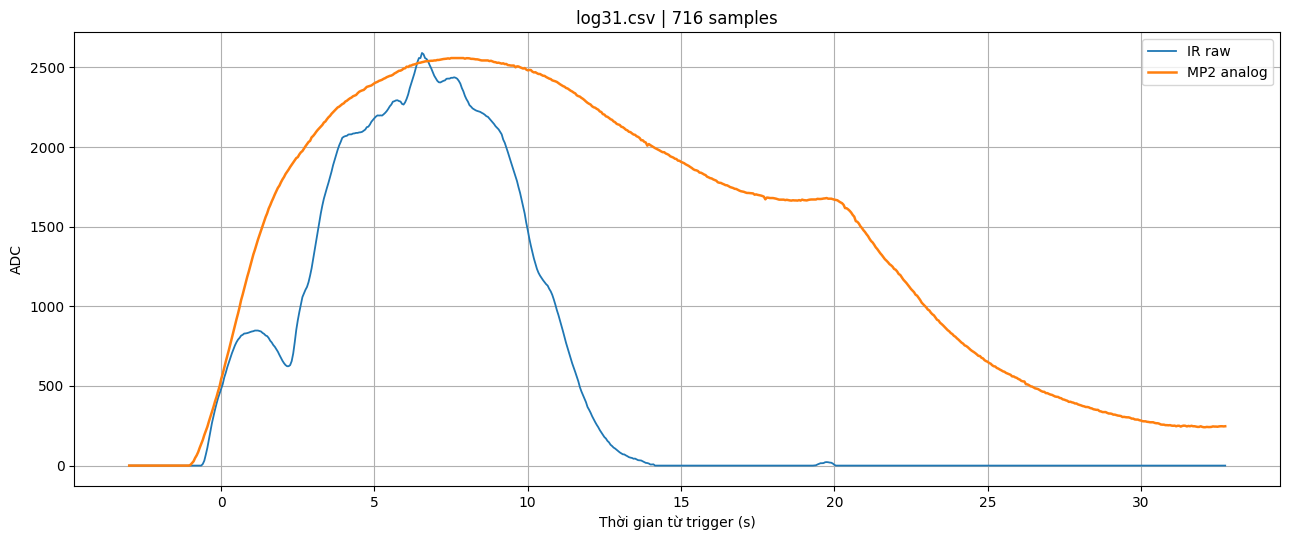

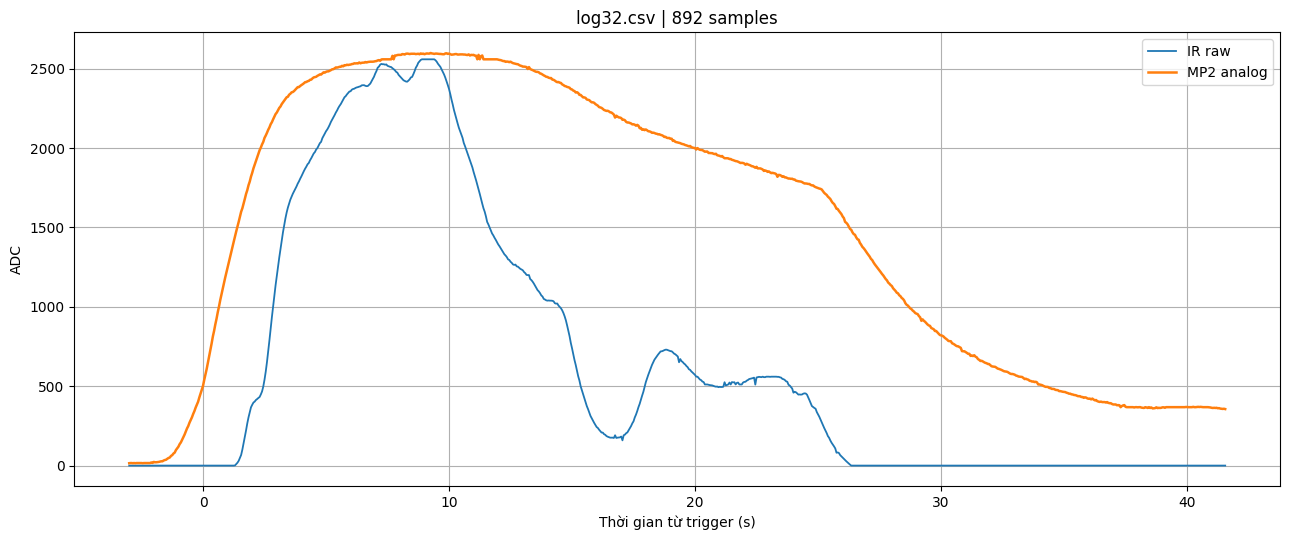

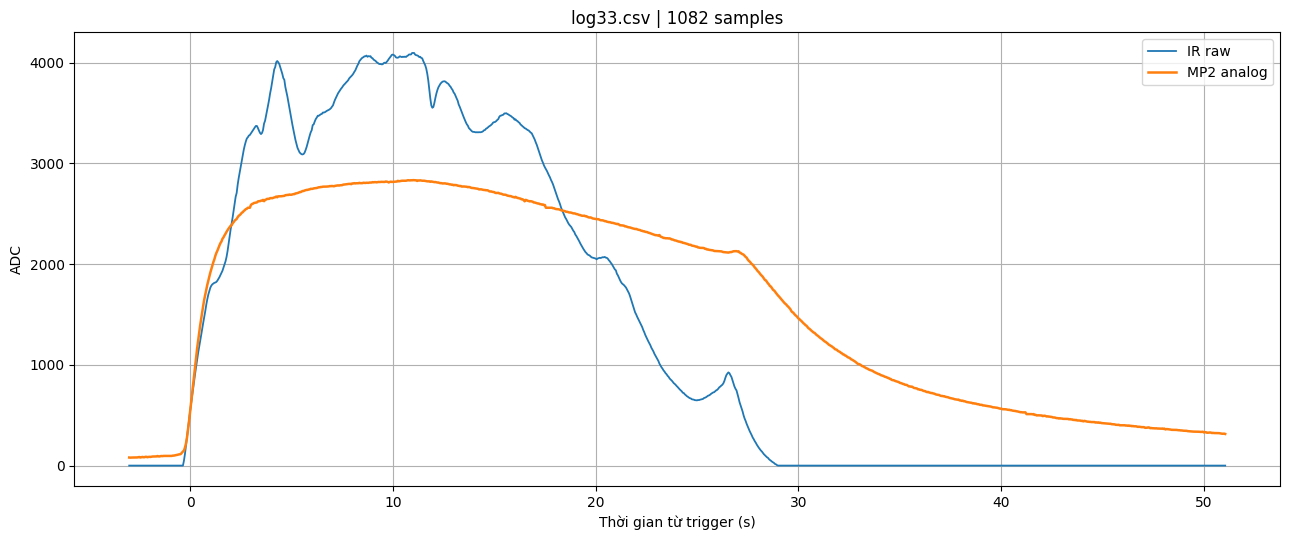

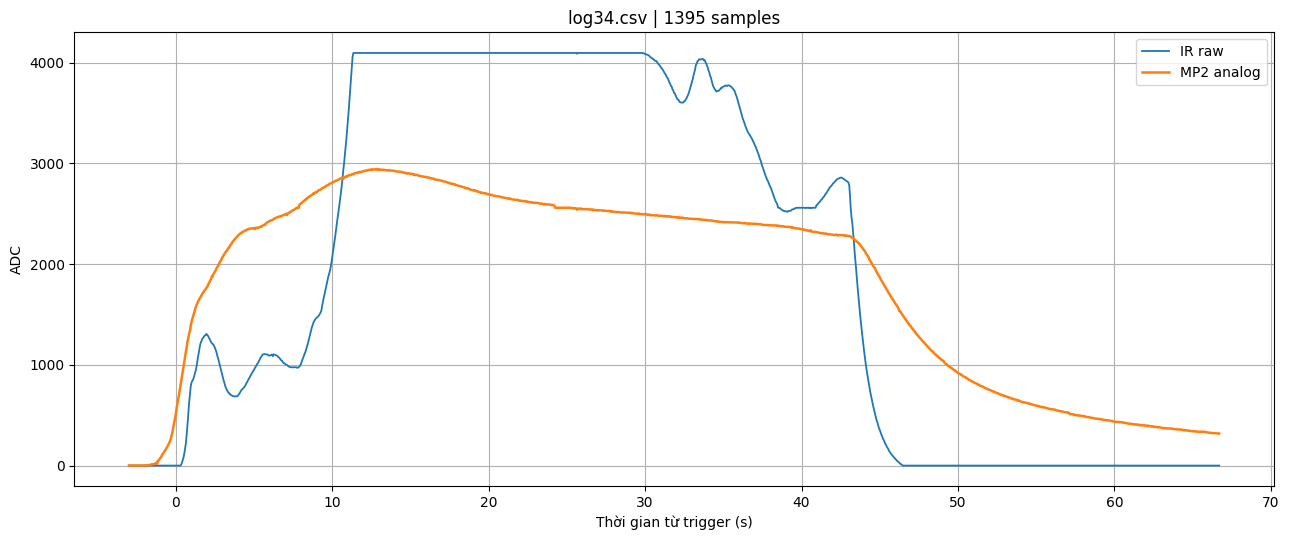

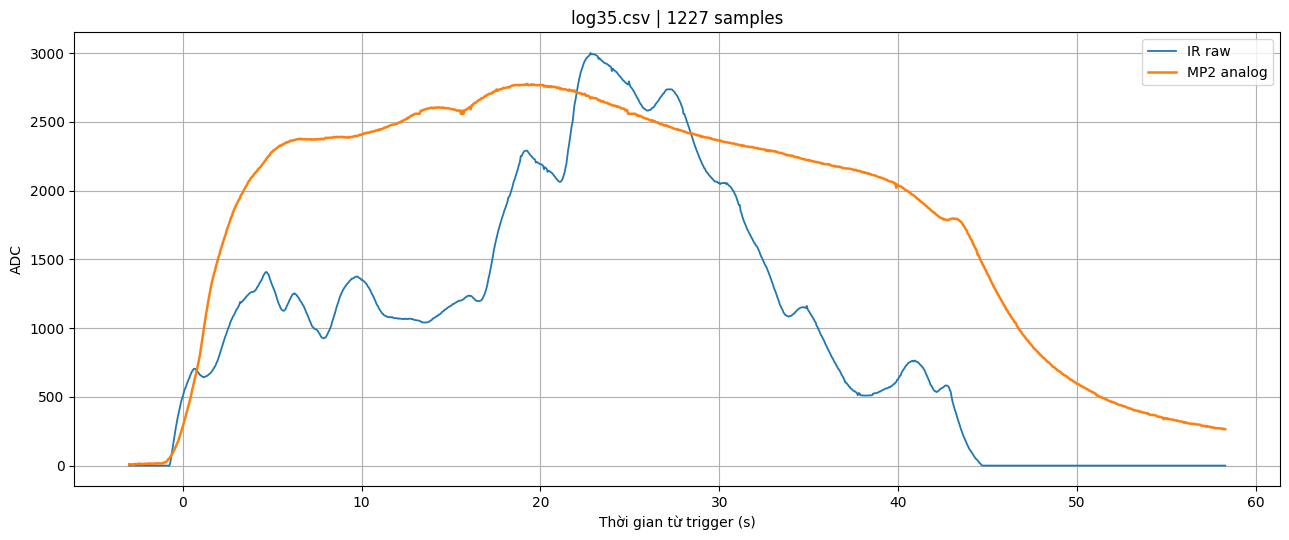

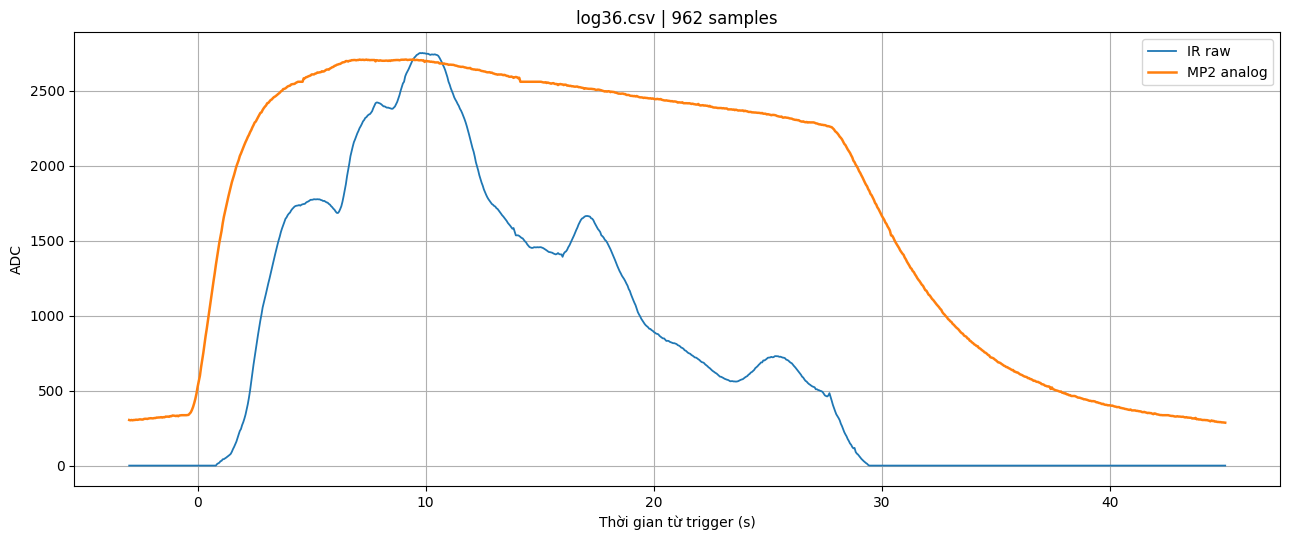

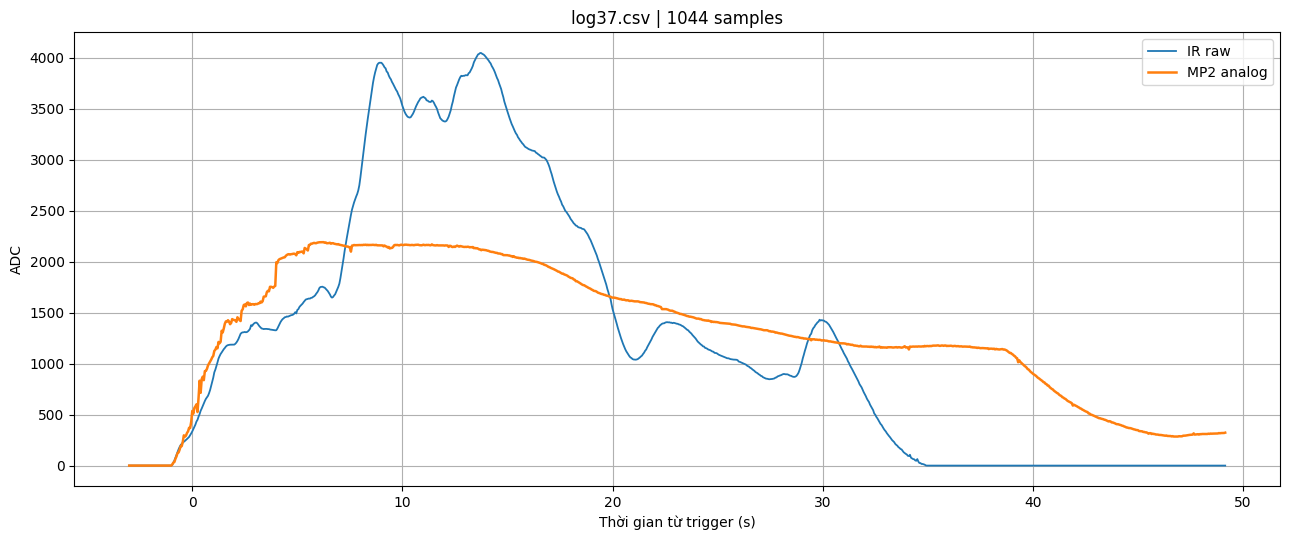

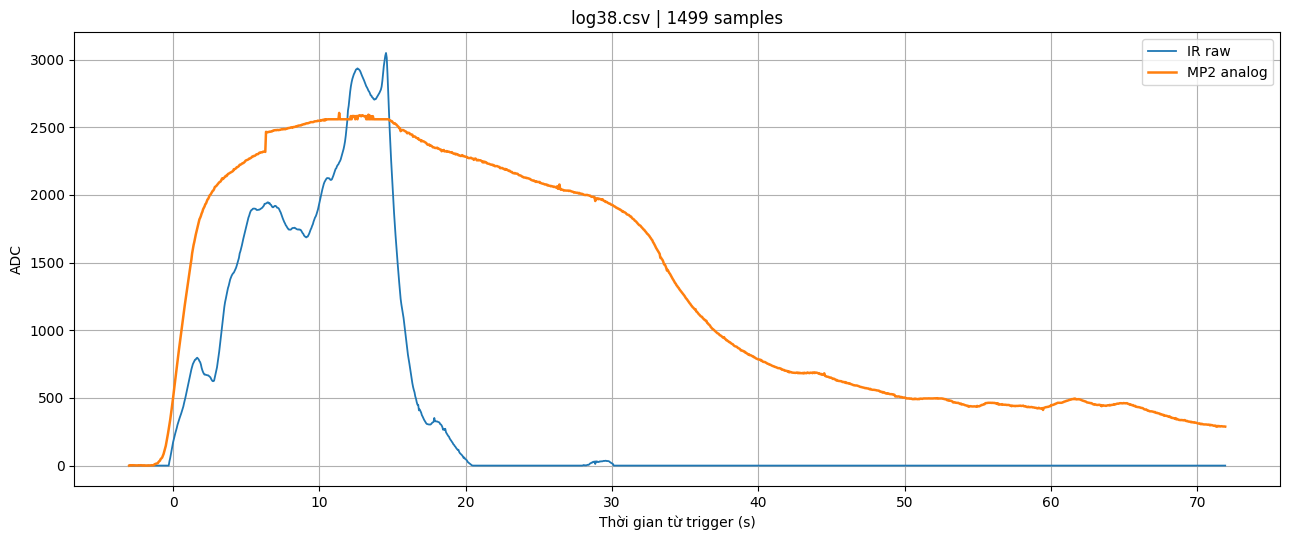

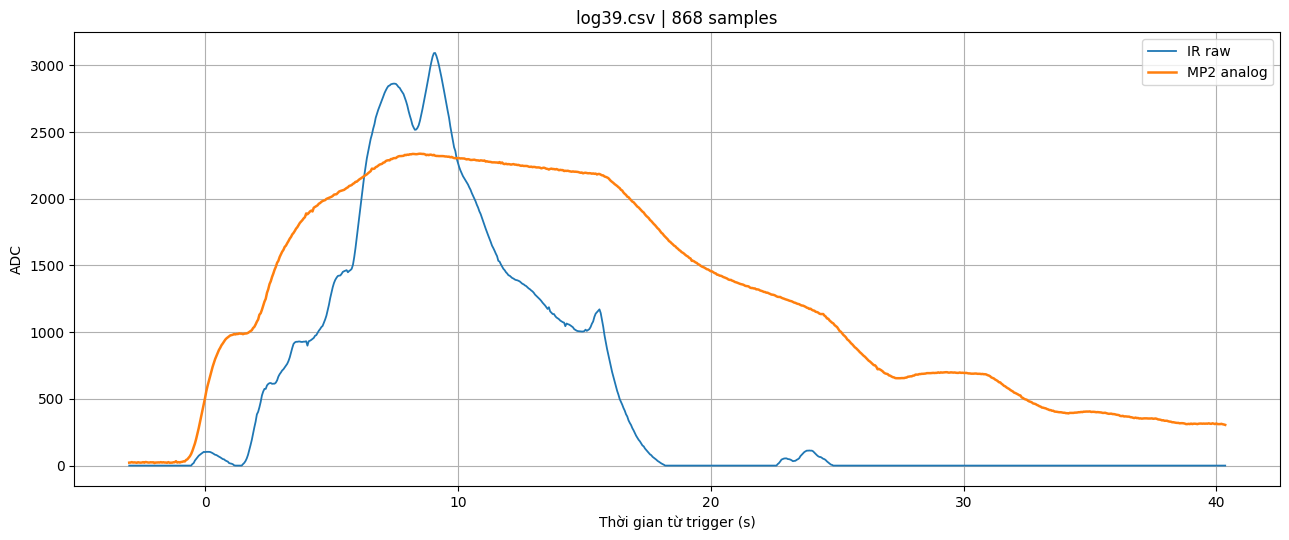

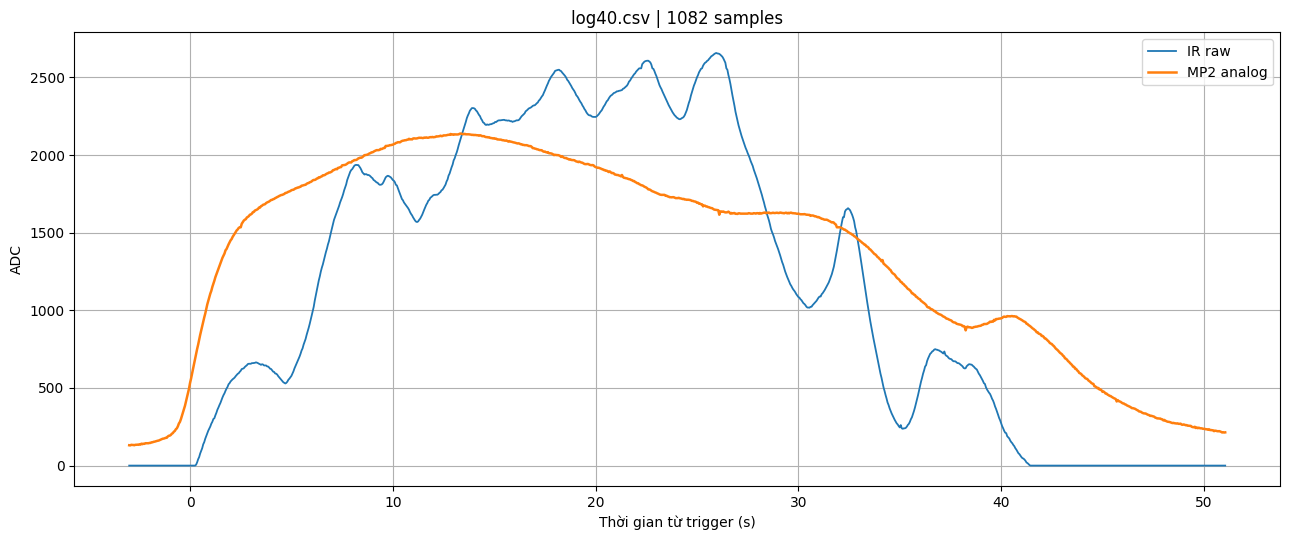

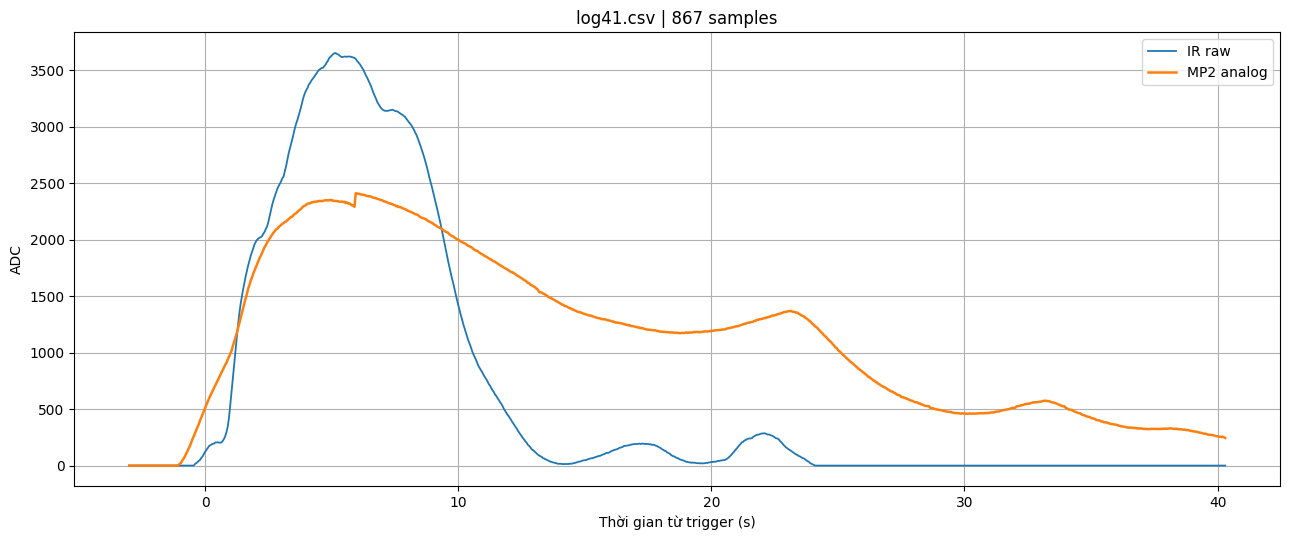

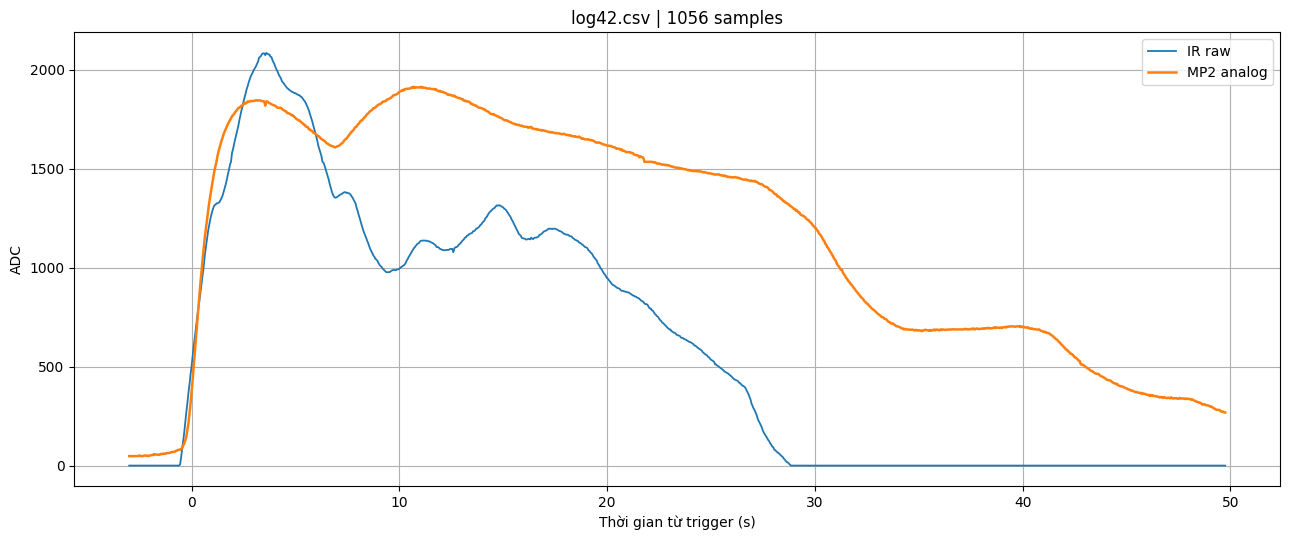

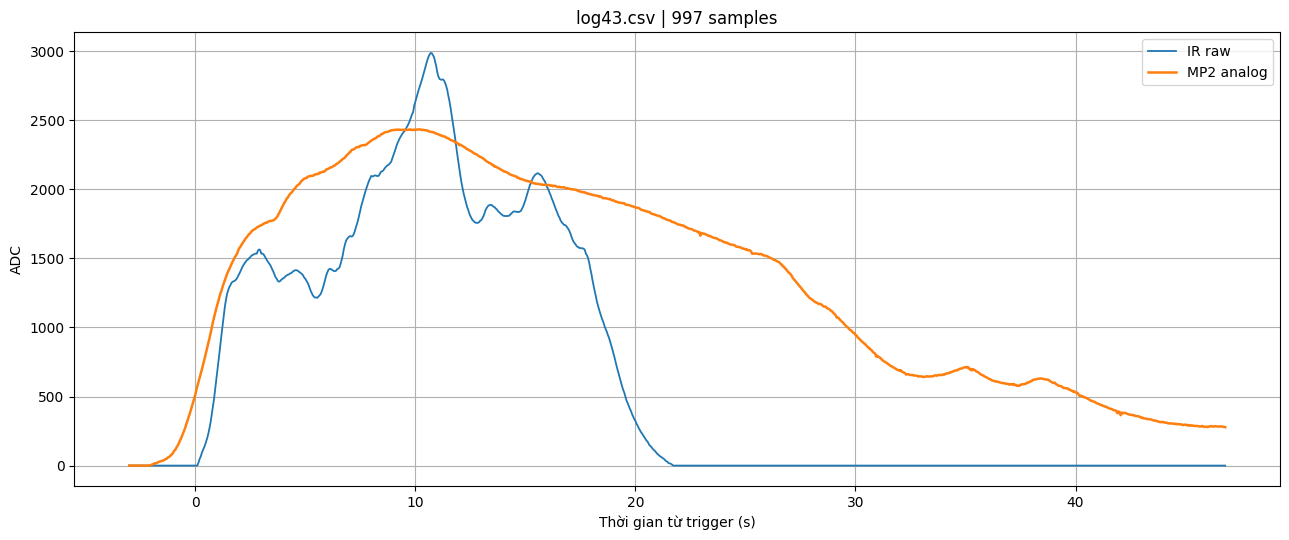

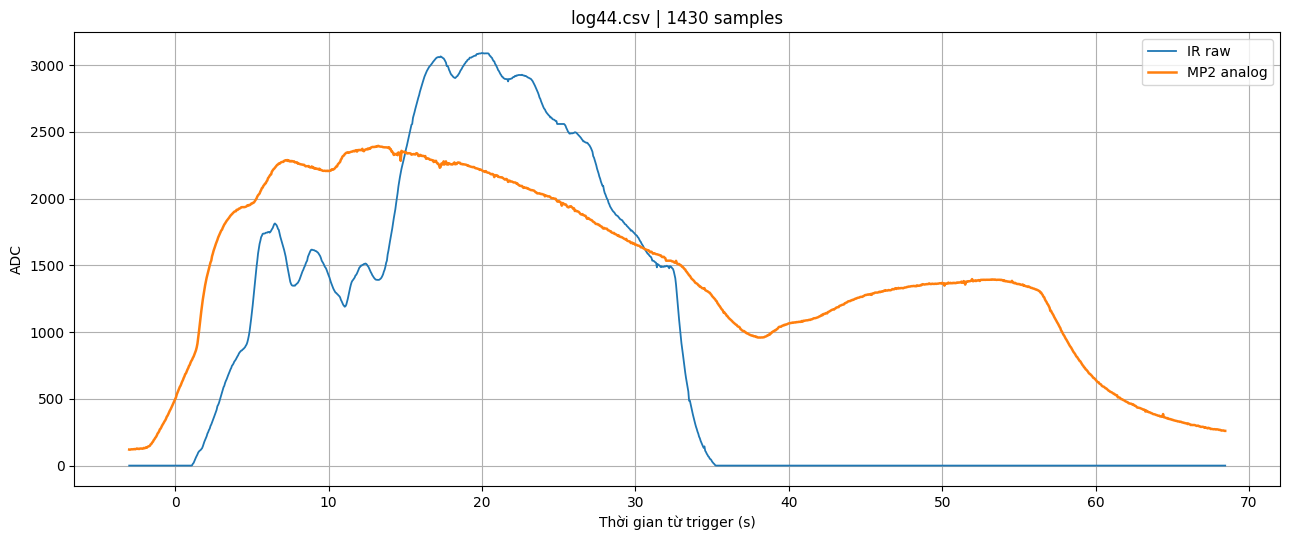

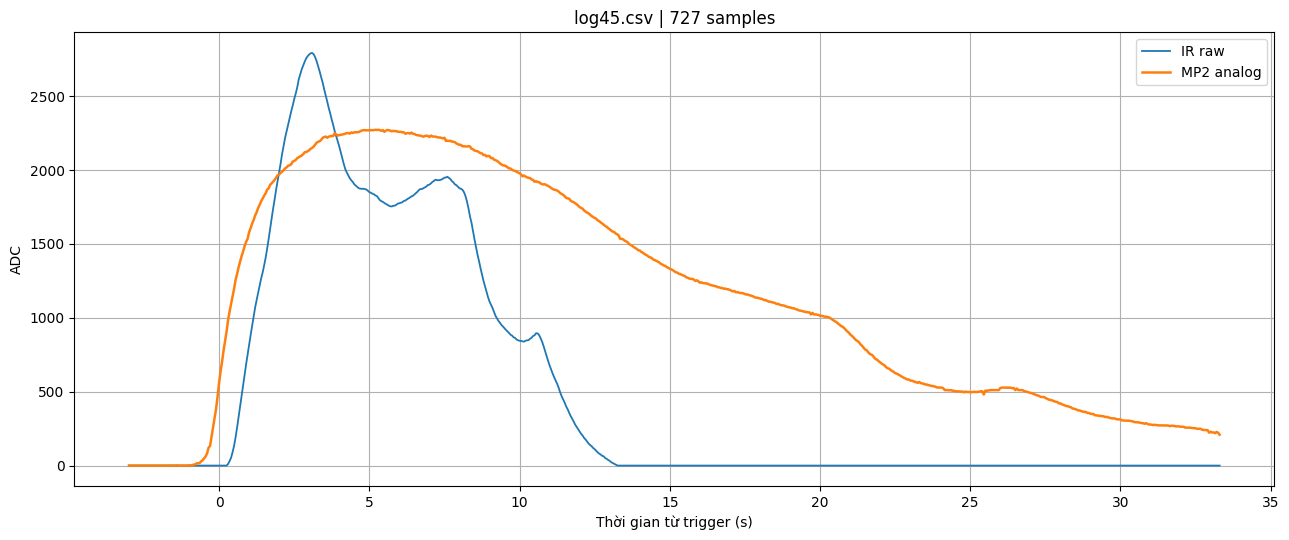

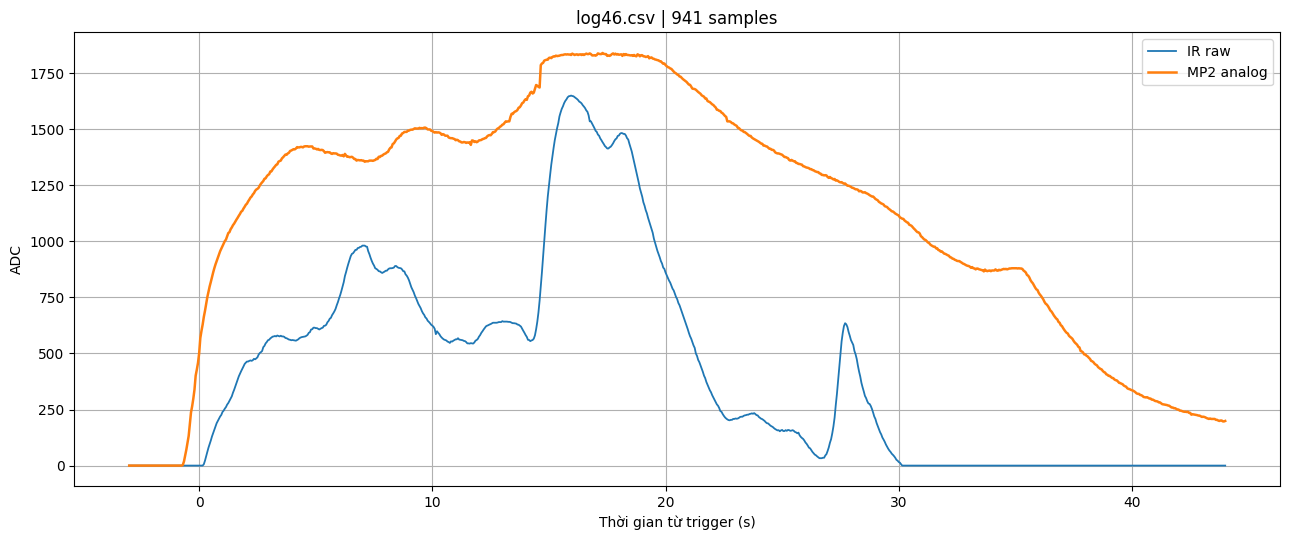

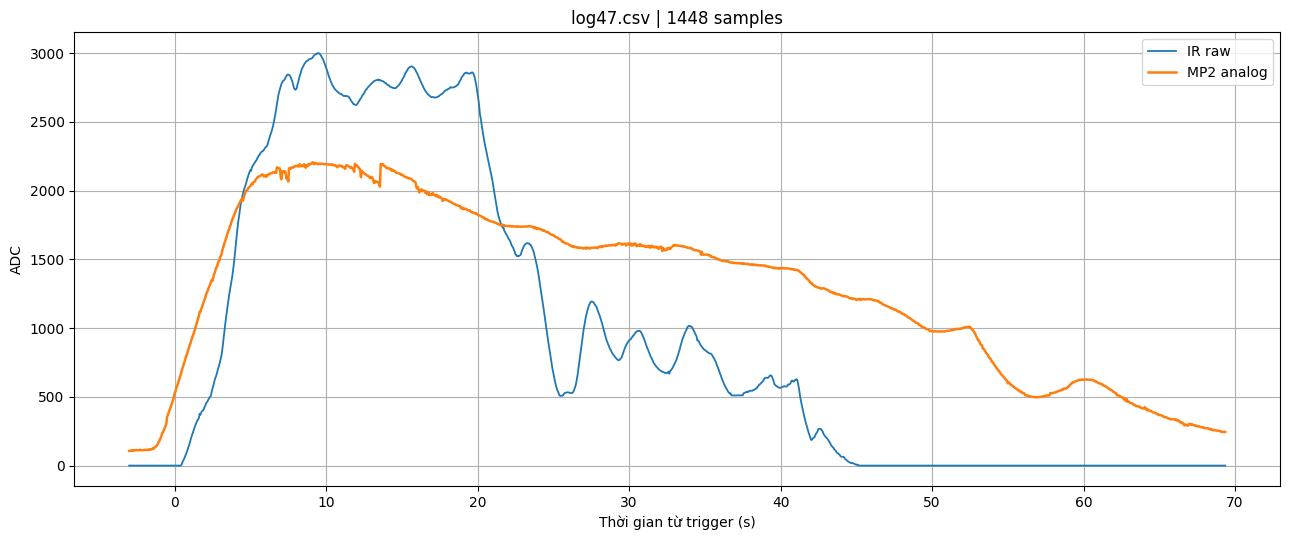

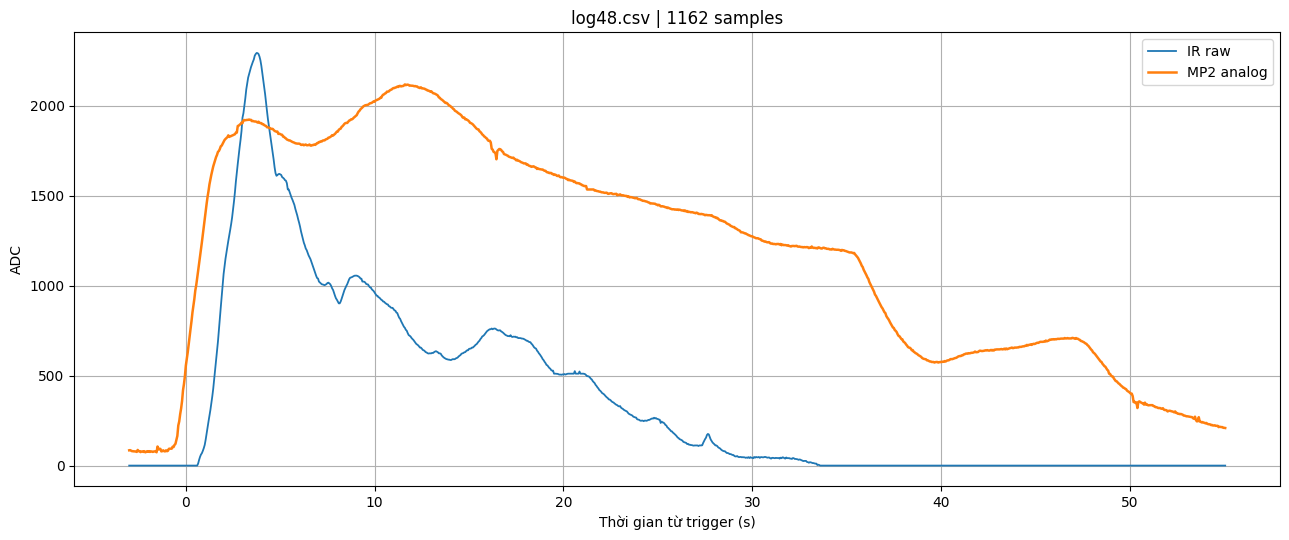

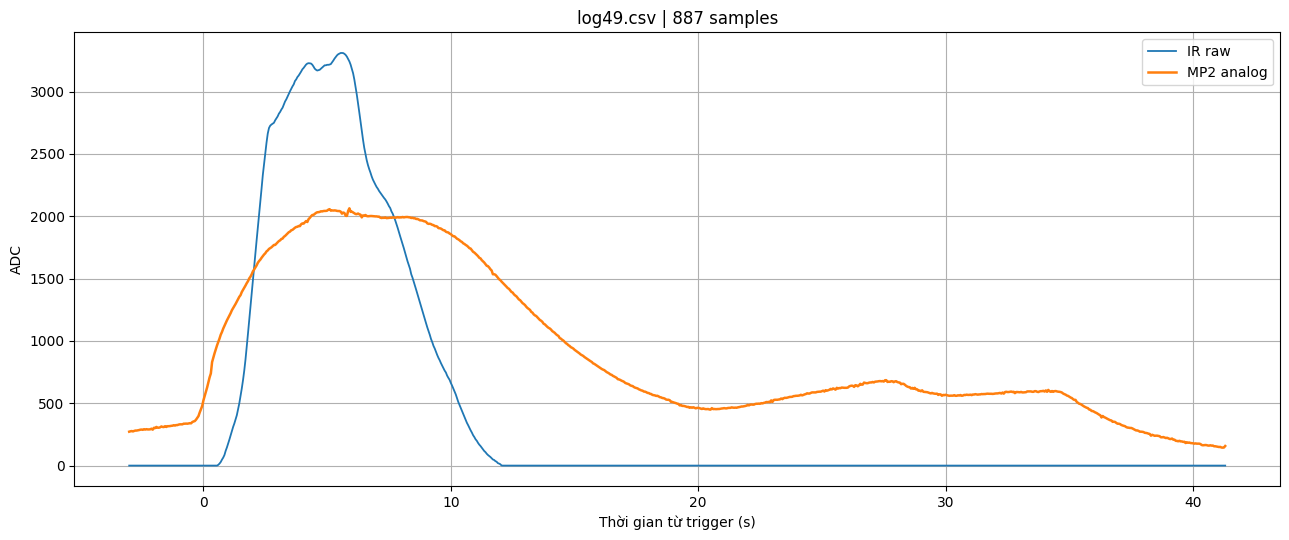

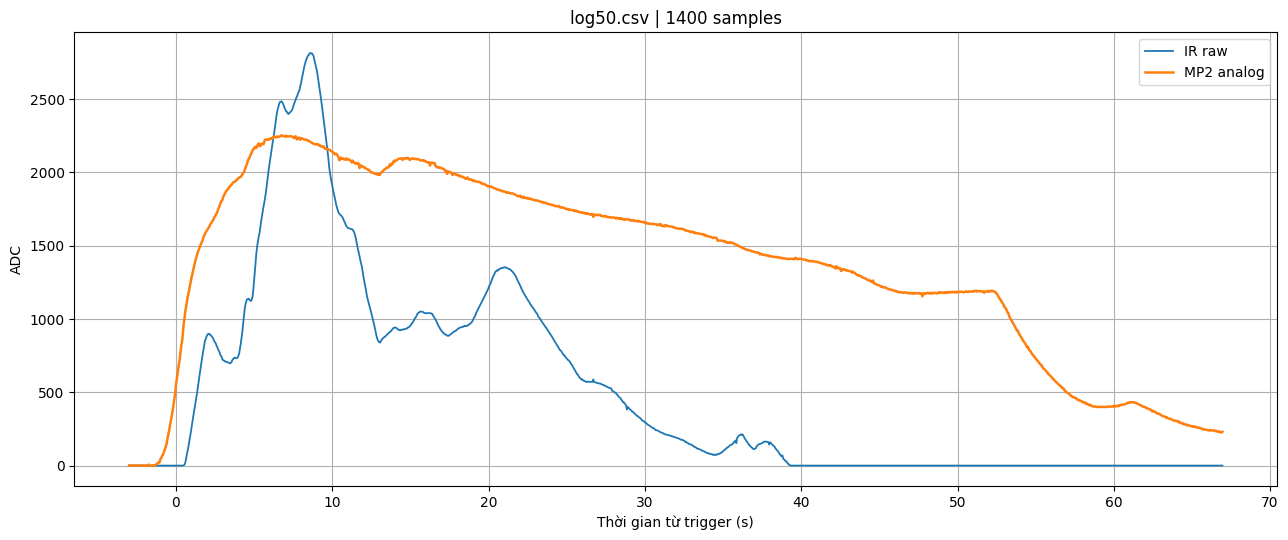

In [3]:
for path in files:
    df = pd.read_csv(path)

    required = {"IR_raw", "MP2_AO_raw"}
    missing = required - set(df.columns)

    if missing:
        print(
            f"Bỏ qua {path.name}: thiếu cột {missing}"
        )
        continue

    if "time_from_trigger_s" in df.columns:
        x = df["time_from_trigger_s"]
        xlabel = "Thời gian từ trigger (s)"
    elif "time_s" in df.columns:
        x = df["time_s"]
        xlabel = "Thời gian (s)"
    elif "sample" in df.columns:
        x = df["sample"]
        xlabel = "Sample"
    else:
        x = np.arange(len(df))
        xlabel = "Index"

    plt.figure(figsize=(13, 5.5))

    plt.plot(
        x,
        df["IR_raw"],
        label="IR raw",
        linewidth=1.3
    )

    plt.plot(
        x,
        df["MP2_AO_raw"],
        label="MP2 analog",
        linewidth=1.8
    )

    plt.xlabel(xlabel)
    plt.ylabel("ADC")
    plt.title(
        f"{path.name} | "
        f"{len(df)} samples"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

## Gợi ý khi lọc dữ liệu

Nên xem xét loại hoặc đo lại các phiên có một trong các dấu hiệu:

- IR bị kẹt ở `0` hoặc `4095` trong thời gian dài.
- IR xuất hiện spike bất thường không tương ứng với quá trình tạo khói.
- MP2 bị nhảy đột ngột, mất tín hiệu hoặc đứng yên bất thường.
- IR có tín hiệu khói rõ nhưng MP2 gần như không phản ứng.
- Thời gian ghi quá ngắn, chưa ghi đủ pha tăng hoặc pha hồi phục.
- Đường tín hiệu khác hoàn toàn với phần lớn các phiên còn lại mà không có lý do thực nghiệm rõ ràng.

Không nên tự động xóa một file chỉ vì tương quan thấp; trước tiên cần xem lại điều kiện thí nghiệm của phiên đó.